# Newton's law of cooling and neural ordinary differential equations (NODEs)

In this notebook we study Newton's law of cooling and then replace the known ODE right-hand side with a neural network to build a NODE model.

In this example we are going to study **Newton's law of cooling**. Hence, we assume a simple (linear) ODE in the form of $$\frac{\mathrm{d}}{\mathrm{d}t}x(t) = -k (x(t)-\vartheta_\mathrm{A}), \quad x_0 = x(t=0)$$ where $x(t)$ is the temperature of a solid body placed in an ambient fluid (e.g., air) having a constant temperature $\vartheta_\mathrm{A})$. Hence, given a thermal conductivity $k$ and initial body temperature $x_0$ the body temperature will converge toward the ambient temperature. 

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.optim import Adam, LBFGS
from scipy.integrate import solve_ivp

torch.manual_seed(140588)
torch.set_default_dtype(torch.float32)
device = torch.device('cpu')

## Ground truth data

We simulate the true cooling process using Newton's law of cooling, then add mild measurement noise.

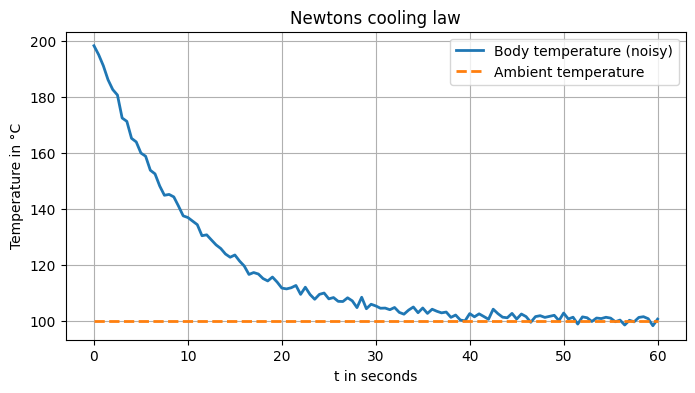

In [3]:
def newtons_cooling(t, x, k, temp_a):
    return -k * (x - temp_a)

k_true = 0.1
temp_a = 100.0
x0 = [200.0]
dt = 0.5
t = np.arange(0.0, 60.0 + dt, dt)

sol = solve_ivp(
    lambda t, x: newtons_cooling(t, x, k_true, temp_a),
    (t[0], t[-1]),
    x0,
    t_eval=t,
    method='RK45'
)
x = sol.y[0]
rng = np.random.default_rng(1234)
y = x + rng.normal(scale=1.0, size=x.shape)

plt.figure(figsize=(8, 4))
plt.plot(t, y, label='Body temperature (noisy)', lw=2)
plt.plot(t, temp_a * np.ones_like(t), '--', label='Ambient temperature', lw=2)
plt.xlabel('t in seconds')
plt.ylabel('Temperature in °C')
plt.title('Newtons cooling law')
plt.legend()
plt.grid(True)
plt.show()

## NODE model definition

We assume the dynamics depend on the current body temperature and the ambient temperature, and we replace the right-hand side with a feedforward neural network.

To study the data-driven modeling approach via **neural ordinary differential equations (NODEs)**, we assume to have no structural knowledge about the ODE's right-hand side. Hence, we replace the entire right-hand side using a simple feedforward artificial neural network (ANN): $$ \frac{\mathrm{d}}{\mathrm{d}t}\hat{x}(t) = \hat{f}_w(x(t), \vartheta_\mathrm{A}).$$ 
The only pre-knowledge we apply to the right-hand side is that it will depend both on the current body temperature $x(t)$ and the ambient temperature $\vartheta_\mathrm{A}$ which is considered a simple constant in this example. Consequently, the ANN representing the ODE has two inputs $(x(t), \vartheta_\mathrm{A})$ and one output $\frac{\mathrm{d}}{\mathrm{d}t}\hat{x}(t)$.

In [ ]:
class NODEModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(2, 10), # 2 inputs: body temperature and ambient temperature to number of outputs in the first hidden layer
            nn.ReLU(), # ReLU activation function
            nn.Linear(10, 10), # hidden layer with 10 neurons
            nn.ReLU(), #ReLU activation function
            nn.Linear(10, 1), # output: rate of change of body temperature
        )

    def forward(self, x, ambient):
        inputs = torch.cat([x, ambient], dim=-1) # concatenate body temperature and ambient temperature into a single input vector. This matches the 2 input features the network expects.
        return self.network(inputs).squeeze(-1) # feeds the concatenated input through the network and returns the predicted rate of change of body temperature. 
        #The squeeze(-1) is used to remove the last dimension, resulting in a 1D tensor of predictions.

def odeint_rk4(func, x0, t, ambient):
    x = x0
    trajectory = [x0]
    for i in range(len(t) - 1):
        dt = t[i + 1] - t[i]
        k1 = func(t[i], x, ambient)
        k2 = func(t[i] + dt / 2, x + dt * k1 / 2, ambient)
        k3 = func(t[i] + dt / 2, x + dt * k2 / 2, ambient)
        k4 = func(t[i] + dt, x + dt * k3, ambient)
        x = x + dt * (k1 + 2*k2 + 2*k3 + k4) / 6
        trajectory.append(x)
    return torch.stack(trajectory)

model = NODEModel().to(device)

#Data Preparation for NODE
ambient_tensor = torch.tensor([[temp_a]], dtype=torch.float32, device=device)
x0_tensor = torch.tensor([200.0], dtype=torch.float32, device=device).unsqueeze(0)
t_tensor = torch.tensor(t, dtype=torch.float32, device=device)

def predict_node(model):
    def f(t_step, x, ambient):
        return model(x, ambient)
    x_traj = odeint_rk4(f, x0_tensor, t_tensor, ambient_tensor)
    return x_traj.squeeze(-1)

target = torch.tensor(y, dtype=torch.float32, device=device)

Data Preparation

ambient_tensor = torch.tensor([[temp_a]], dtype=torch.float32, device=device): This takes the constant ambient temperature (temp_a). The double brackets [[ ]] shape it into a 2D tensor (like a matrix with one row and one column). It also ensures the number is a 32-bit float and loads it onto the specified computation hardware (the device, which is the CPU here).<br>

x0_tensor = torch.tensor([200.0], ...).unsqueeze(0): This converts the initial body temperature (200.0°C) into a tensor. The .unsqueeze(0) command adds an extra, empty dimension to the front of the tensor. This is done because PyTorch neural networks generally expect inputs in "batches" (e.g., [batch_size, features]), so this formats the single temperature value correctly for the model. <br>

t_tensor = torch.tensor(t, ...): This simply converts the sequence of time steps (t) from a NumPy array into a PyTorch tensor so the custom ODE solver can use it. <br>

The prediction function

This function serves as the central command to run your neural ODE model and generate a full temperature curve <br>

def f(t_step, x, ambient): return model(x, ambient): The ODE solver (odeint_rk4) expects a function that takes time, state, and parameters to calculate the current slope (rate of change). This tiny inner function f satisfies that requirement by wrapping your neural network. Notice that it receives t_step but ignores it—this is because Newton's law of cooling only depends on the current temperatures, not on what time of day it is <br>

x_traj = odeint_rk4(f, x0_tensor, t_tensor, ambient_tensor): This line fires off the custom Runge-Kutta 4 numerical solver. It tells the solver: "Start at x0, use the neural network f to calculate the temperature change, and step forward through all the times in t_tensor while keeping the ambient_tensor constant". The result (x_traj) is the full predicted trajectory. <br>

return x_traj.squeeze(-1): The neural network outputs data with extra dimensions (because of the batching requirement mentioned earlier). The .squeeze(-1) command strips away that last unnecessary dimension, flattening the trajectory into a simple 1D list of temperatures. <br>

target = torch.tensor(y, dtype=torch.float32, device=device): Finally, this takes the noisy "ground truth" data y (the simulated sensor readings) and turns it into a tensor. This target tensor is what the model's predictions will be compared against later to calculate the error (loss) during the training loop. <br>


## Model fitting

We optimize the neural ODE parameters by minimizing the squared prediction error against the noisy training data.

This block of code is the heart of the machine learning process: the **training loop**. It is where the neural network actually learns to mimic the physical cooling process by adjusting its internal parameters based on its mistakes.

Here is a step-by-step breakdown of what these lines do:

### 1. Setting up the Optimizer

* `optimizer = Adam(model.parameters(), lr=1e-2)`: This initializes the Adam optimizer, which is the algorithm responsible for tweaking the neural network's weights. You are telling it to optimize the `model.parameters()` and setting the learning rate (`lr`) to 0.01, which controls how big of a step the optimizer takes when adjusting the weights.



### 2. The Training Loop (2000 Epochs)

The `for epoch in range(2000):` loop runs the training process 2,000 times. Inside this loop, a strict sequence of PyTorch commands is executed every single time:

* `optimizer.zero_grad()`: This clears out the "gradients" (the calculated direction to adjust the weights) from the previous loop. If you do not do this, the math from old steps will accumulate and ruin the current step.


* `pred = predict_node(model)`: This runs the forward pass. The neural network and custom ODE solver generate a full predicted temperature trajectory based on its current, imperfect weights.


* `loss = torch.mean((pred - target)  2)`: This calculates the Mean Squared Error (MSE). It measures exactly how far off the predicted temperatures are from the noisy `target` data, squaring the differences so negative and positive errors don't cancel each other out, and taking the average.


* `loss.backward()`: This is the backpropagation step. PyTorch works backward through the entire ODE solver and neural network to calculate exactly how much each individual weight contributed to the `loss`.


* `optimizer.step()`: The optimizer looks at the gradients calculated in the previous step and updates the network's weights to make the prediction slightly better for the next loop.


* `if epoch % 250 == 0:`: Every 250 loops, it prints the current loss to the screen so you can verify that the error is actually decreasing over time.



### 3. Finalizing the Prediction for Plotting

* `pred = predict_node(model).detach().cpu().numpy()`: After the 2,000 epochs are finished, the model is fully trained. This line runs the model one last time to get the final trajectory.


* `.detach()` unhooks the result from PyTorch's gradient-tracking engine because you no longer need to train on it.


* `.cpu()` ensures the data is on the system's main memory (in case it was being trained on a GPU).


* `.numpy()` converts the PyTorch tensor back into a standard Python NumPy array so that Matplotlib can understand it.





### 4. Plotting the Results

* The final block of `plt` commands generates a visual graph. It overlays the noisy training data, the constant ambient temperature line, and the newly learned smooth `NODE prediction` curve so you can visually evaluate how well the neural network learned the underlying physics.

Epoch 0: loss = 145081188352.000000
Epoch 250: loss = 2574.886719
Epoch 500: loss = 1514.228149
Epoch 750: loss = 1098.374146
Epoch 1000: loss = 955.916565
Epoch 1250: loss = 903.856567
Epoch 1500: loss = 883.993774
Epoch 1750: loss = 873.577820


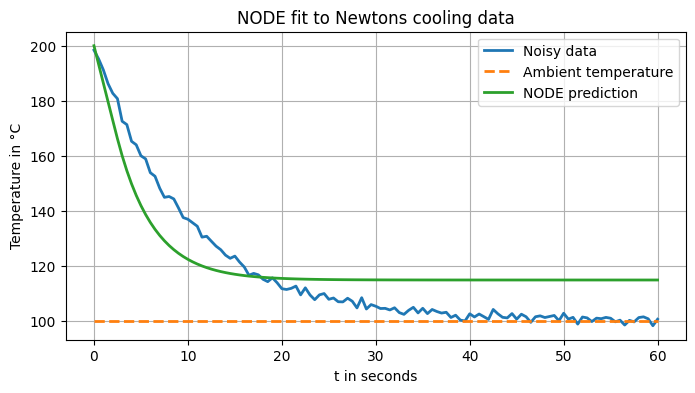

In [5]:
optimizer = Adam(model.parameters(), lr=1e-2)

for epoch in range(2000):
    optimizer.zero_grad()
    pred = predict_node(model)
    loss = torch.mean((pred - target) ** 2)
    loss.backward()
    optimizer.step()
    if epoch % 250 == 0:
        print(f'Epoch {epoch}: loss = {loss.item():.6f}')

pred = predict_node(model).detach().cpu().numpy()

plt.figure(figsize=(8, 4))
plt.plot(t, y, label='Noisy data', lw=2)
plt.plot(t, temp_a * np.ones_like(t), '--', label='Ambient temperature', lw=2)
plt.plot(t, pred, label='NODE prediction', lw=2)
plt.xlabel('t in seconds')
plt.ylabel('Temperature in °C')
plt.title('NODE fit to Newtons cooling data')
plt.legend()
plt.grid(True)
plt.show()

### Remedy 1: limit the right-hand side output using tanh activation functions

Replacing the hidden-layer activations with `tanh` can reduce large output values and improve stability.

In our previous undertakings, we have used ADAM solver for optimization and ReLU activation. But using normal optimizer would crash the simulation due to numerics. And so using ADAM optimizer may solve the ODE predicted by the NN but the system may still seem unstable due to numerics (invalid input and output predictions or invalid parameter prediction). So, using ativations will bound the numerics (-1 to +1) such that the system will not go unstable. Here, Tanh activation is used to bound the numerics.   

Epoch 0: loss = 7267.932129
Epoch 250: loss = 3689.175049
Epoch 500: loss = 3687.607422
Epoch 750: loss = 3687.137451
Epoch 1000: loss = 3686.902344
Epoch 1250: loss = 3686.823486
Epoch 1500: loss = 3686.745361
Epoch 1750: loss = 3686.745361


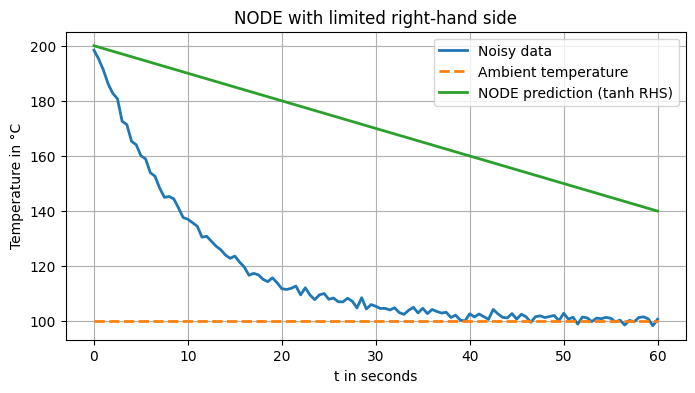

In [6]:
class NODEModelTanh(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(2, 10),
            nn.Tanh(),
            nn.Linear(10, 10),
            nn.Tanh(),
            nn.Linear(10, 1),
            nn.Tanh(),
        )

    def forward(self, x, ambient):
        inputs = torch.cat([x, ambient], dim=-1)
        return self.network(inputs).squeeze(-1)

model_tanh = NODEModelTanh().to(device)
optimizer_tanh = Adam(model_tanh.parameters(), lr=1e-2)

for epoch in range(2000):
    optimizer_tanh.zero_grad()
    pred = predict_node(model_tanh)
    loss = torch.mean((pred - target) ** 2)
    loss.backward()
    optimizer_tanh.step()
    if epoch % 250 == 0:
        print(f'Epoch {epoch}: loss = {loss.item():.6f}')

pred_tanh = predict_node(model_tanh).detach().cpu().numpy()

plt.figure(figsize=(8, 4))
plt.plot(t, y, label='Noisy data', lw=2)
plt.plot(t, temp_a * np.ones_like(t), '--', label='Ambient temperature', lw=2)
plt.plot(t, pred_tanh, label='NODE prediction (tanh RHS)', lw=2)
plt.xlabel('t in seconds')
plt.ylabel('Temperature in °C')
plt.title('NODE with limited right-hand side')
plt.legend()
plt.grid(True)
plt.show()

### Remedy 3: standardize the NODE data

Standardizing the input and output time series can improve optimization behavior for the NODE.

Epoch 0: loss = 16.887812
Epoch 250: loss = 1.317985
Epoch 500: loss = 1.294054
Epoch 750: loss = 1.286447
Epoch 1000: loss = 1.283157
Epoch 1250: loss = 1.281429
Epoch 1500: loss = 1.280399
Epoch 1750: loss = 1.279729


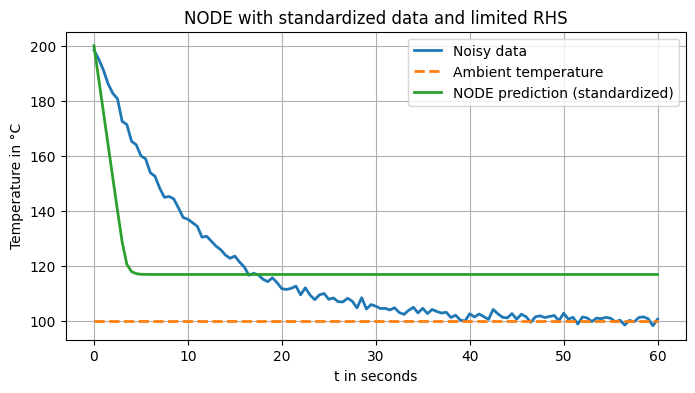

In [7]:
y_mean = y.mean()
y_std = y.std()
y_std = y_std if y_std > 0 else 1.0

y_norm = (y - y_mean) / y_std
ambient_norm = (temp_a - y_mean) / y_std
x0_norm = (x0[0] - y_mean) / y_std

target_norm = torch.tensor(y_norm, dtype=torch.float32, device=device)
x0_norm_tensor = torch.tensor([x0_norm], dtype=torch.float32, device=device).unsqueeze(0)
ambient_norm_tensor = torch.tensor([[ambient_norm]], dtype=torch.float32, device=device)

def predict_node_norm(model):
    def f(t_step, x, ambient):
        return model(x, ambient)
    x_traj = odeint_rk4(f, x0_norm_tensor, t_tensor, ambient_norm_tensor)
    return x_traj.squeeze(-1)

model_norm = NODEModelTanh().to(device)
optimizer_norm = Adam(model_norm.parameters(), lr=1e-2)

for epoch in range(2000):
    optimizer_norm.zero_grad()
    pred = predict_node_norm(model_norm)
    loss = torch.mean((pred - target_norm) ** 2)
    loss.backward()
    optimizer_norm.step()
    if epoch % 250 == 0:
        print(f'Epoch {epoch}: loss = {loss.item():.6f}')

pred_norm = predict_node_norm(model_norm).detach().cpu().numpy()
pred_reconstructed = pred_norm * y_std + y_mean

plt.figure(figsize=(8, 4))
plt.plot(t, y, label='Noisy data', lw=2)
plt.plot(t, temp_a * np.ones_like(t), '--', label='Ambient temperature', lw=2)
plt.plot(t, pred_reconstructed, label='NODE prediction (standardized)', lw=2)
plt.xlabel('t in seconds')
plt.ylabel('Temperature in °C')
plt.title('NODE with standardized data and limited RHS')
plt.legend()
plt.grid(True)
plt.show()